# Thresholding the Image

## Description
Thresholding can be approached in different ways:
- A **manual threshold** can be selected by inspecting the image and choosing a value that visually separates the objects.
- Alternatively, a **systematic method** like **Otsu's thresholding** can be used. Otsu's algorithm automatically determines an optimal threshold by minimizing the variance within each class (foreground and background).

In this step, we apply both a custom implementation of Otsu's method.

## Part of Pipeline
- **Previous Step**: Creating Synthetic 3D Image
- **Next Step**: Calculating the Distance Transform

## Requirements
- Python 3.11
- Libraries:
  - matplotlib
  - numpy

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from src.visualisation import (
    plot_2d_slice_with_values,
    plot_hist,
    plot_panels,
)

# Integrate figures into notebook
%matplotlib notebook
%matplotlib inline
plt.close()

### Load the synthetic image from the previous step

We start by loading up the synthetic image, a cubic volume containing multiple spheres.

In [10]:
# Load synthetic image
image3d = np.load(file='../src/data/synthetic_image.npy')

### Step 1 — Flatten intensities and validate input

Otsu’s method expects **integer-valued** intensity levels (e.g., `uint8` or `uint16`), because it operates over a discrete histogram.
We first flatten the 3D volume to a 1D array of voxel values and ensure the dtype is integer-based.


In [11]:

# Use your 3D image volume (e.g., 'image3d' from the previous notebook section)
voxels = image3d.ravel()

# Sanity check: Otsu assumes discrete intensities
if not np.issubdtype(voxels.dtype, np.integer):
    raise ValueError(f"Input must be integer-valued, got dtype={voxels.dtype}")

print("Voxel count:", voxels.size)
print("dtype:", voxels.dtype)
print("min/max:", voxels.min(), voxels.max())


Voxel count: 4096
dtype: uint8
min/max: 8 197


### Step 2 — Histogram of intensities

We compute the **frequency** of each intensity level using `np.bincount` (efficient for integer arrays).
For `uint8`, the histogram has length 256; for `uint16`, length 65,536.


Histogram length: 198
Total count matches voxels: True


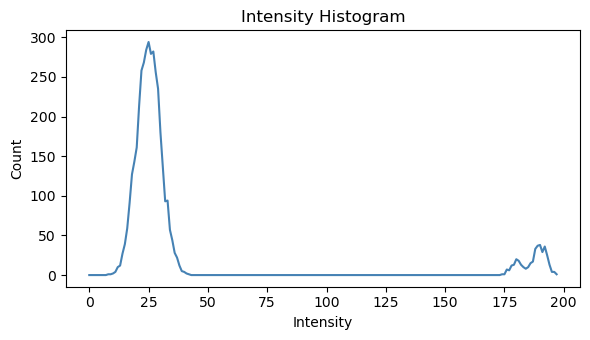

In [12]:
# Maximum value in your actual data
max_val = voxels.max()
hist = np.bincount(voxels, minlength=max_val + 1).astype(float)

print("Histogram length:", len(hist))
print("Total count matches voxels:", int(hist.sum()) == voxels.size)

# Optional: quick histogram plot (no threshold yet)
plot_hist(voxels, bins=max_val + 1, t=None, title="Intensity Histogram")



### Step 3 — Probability distribution and cumulative statistics

Let $p(i)$ be the probability of intensity $i$, i.e., `hist / hist.sum()`.
We then compute cumulative probability $\omega(t) = \sum_{i \le t} p(i)$ and cumulative mean $\mu(t) = \sum_{i \le t} i \cdot p(i)$.
The **global mean** $\mu_T$ is the mean intensity of the entire image.


In [13]:
prob = hist / hist.sum()                          # p(i)
cum_prob = np.cumsum(prob)                        # ω(t)
cum_mean = np.cumsum(prob * np.arange(len(prob))) # μ(t)
mean_total = cum_mean[-1]                         # μ_T

print("Global mean (μ_T):", mean_total)
# Basic checks
assert np.isclose(prob.sum(), 1.0), "Probability must sum to 1"
assert np.isclose(cum_prob[-1], 1.0), "Cumulative probability must end at 1"


Global mean (μ_T): 39.734130859375


### Step 4 — Between-class variance and optimal threshold

Otsu’s method selects the threshold $t$ that **maximizes** the between-class variance:
$\sigma_b^2(t) = \frac{\big(\mu_T \cdot \omega(t) - \mu(t)\big)^2}{\omega(t) \cdot (1 - \omega(t))}$

This is equivalent to the classic form:
$\sigma_b^2(t) = \omega_b \cdot \omega_f \cdot (\mu_b - \mu_f)^2$

We compute \(\sigma_b^2(t)\) for every possible \(t\) and take `argmax`.

In [14]:
# Avoid division by zero when ω(t)=0 or 1 using np.divide with 'where'
den = cum_prob * (1 - cum_prob)
variance = np.divide(
    (mean_total * cum_prob - cum_mean) ** 2,
    den,
    out=np.zeros_like(cum_prob),
    where=den != 0,
)

t_otsu = int(np.argmax(variance))
print("Otsu threshold:", t_otsu)


Otsu threshold: 42


### Step 5 — Visual check

Plot the histogram with the Otsu threshold overlaid.
This helps you judge whether the chosen \(t\) sensibly splits the modes in the intensity distribution.


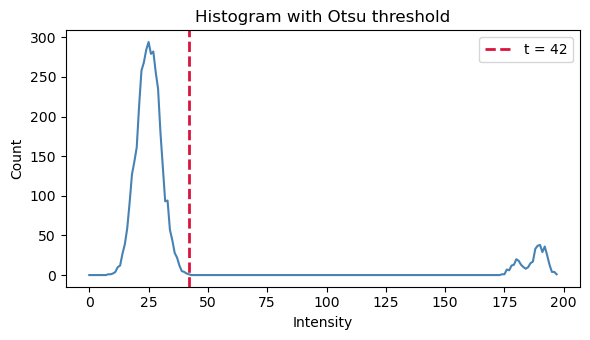

In [15]:
# Plot histogram with overlaid Otsu threshold
plot_hist(voxels, bins=max_val + 1, t=t_otsu, title="Histogram with Otsu threshold")

### Step 6 — Apply threshold to segment

We now binarize the volume using the selected threshold:
- **Foreground**: voxels with intensity **≥** \(t\)
- **Background**: voxels with intensity **<** \(t\)

We’ll visualize a central slice of the binary mask.

Foreground voxel count: 372


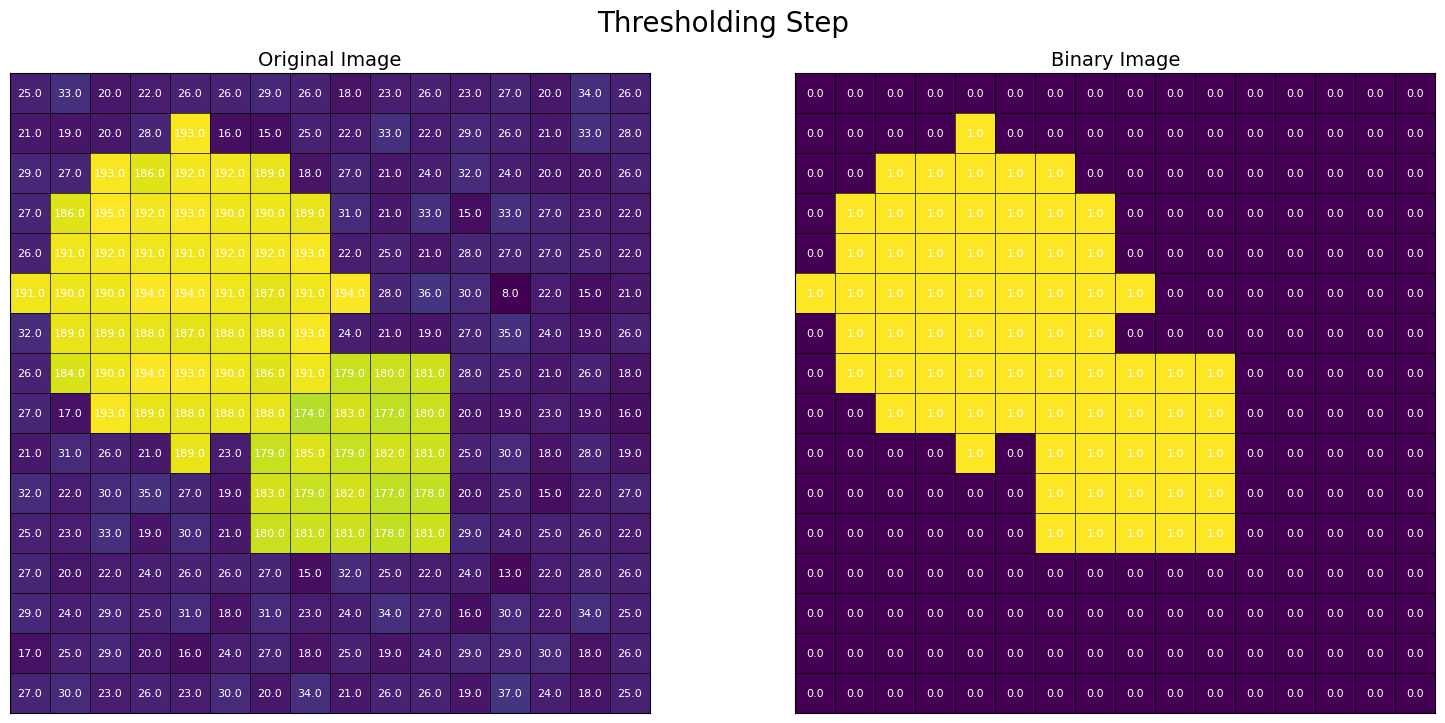

In [16]:
# Create binary image
binary_image = (image3d >= t_otsu).astype(np.uint8)
print("Foreground voxel count:", int(binary_image.sum()))

# Write synthetic image out
np.save(file='../src/data/binary_image.npy', arr=binary_image)

# Visualize a single 2D slice of the original data and the binary image
plot_slice_index = 7 # Slice index to be visualised
plot_panels(
    n=2,
    data_list=[image3d,binary_image],
    plot_func=plot_2d_slice_with_values,
    plot_kwargs_list=[{"slice_index": plot_slice_index}, {"slice_index": plot_slice_index}],
    title="Thresholding Step",
    subtitles=["Original Image", "Binary Image"]
)

**Exercise 1:** Go back to Section 1 and modify the sphere intensities so they are closer together (e.g., 180 and 190) or closer to the background (e.g., 30 and 50).
Re-run Otsu thresholding.
- Does Otsu still separate foreground and background correctly?
- What happens when the intensity difference becomes very small?

**Exercise 2:** Compute Otsu threshold only for a region of interest (e.g., center cube).
Compare it to the global threshold.
- Which one gives better segmentation for that region?
